In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d
plt.style.use('_mpl-gallery')
pd.set_option("display.precision", 4)

s11 = pd.read_csv('data/sim1.csv')
s12 = pd.read_csv('data/sim1_no.csv')
s11mean = s11.groupby(['N', 'P'])[['MSEA', 'MSEV']].mean().reset_index()
s12mean = s12.groupby(['N', 'P'])[['MSEA', 'MSEV']].mean().reset_index()
s11mean

,N,P,MSEA,MSEV
0,5000,3,0.0434,0.0206
1,5000,10,0.0427,0.0117
2,5000,20,0.0428,0.0110
3,5000,25,0.0421,0.0157
4,10000,3,0.0277,0.0242
5,10000,10,0.0283,0.0091
6,10000,20,0.0280,0.0064
7,10000,25,0.0283,0.0105
8,20000,3,0.0169,0.0022
9,20000,10,0.0171,0.0021


In [2]:
s12mean

,N,P,MSEA,MSEV
0,5000,3,0.0947,0.0222
1,5000,10,0.6488,0.3708
2,5000,20,1.2960,1.4762
3,5000,25,1.5220,2.1521
4,10000,3,0.0618,0.0090
5,10000,10,0.5156,0.2165
6,10000,20,1.1232,1.1237
7,10000,25,1.3434,1.6418
8,20000,3,0.0405,0.0033
9,20000,10,0.4117,0.1316


In [3]:
p3_1 = s11mean.loc[s11mean['P'] == 3, ['N', 'MSEA', 'MSEV']].reset_index(drop=True)
p10_1 = s11mean.loc[s11mean['P'] == 10, ['MSEA', 'MSEV']].reset_index(drop=True)
p20_1 = s11mean.loc[s11mean['P'] == 20, ['MSEA', 'MSEV']].reset_index(drop=True)
p25_1 = s11mean.loc[s11mean['P'] == 25, ['MSEA', 'MSEV']].reset_index(drop=True)

p3_2 = s12mean.loc[s11mean['P'] == 3, ['N', 'MSEA', 'MSEV']].reset_index(drop=True)
p10_2 = s12mean.loc[s11mean['P'] == 10, ['MSEA', 'MSEV']].reset_index(drop=True)
p20_2 = s12mean.loc[s11mean['P'] == 20, ['MSEA', 'MSEV']].reset_index(drop=True)
p25_2 = s12mean.loc[s11mean['P'] == 25, ['MSEA', 'MSEV']].reset_index(drop=True)

df1 = pd.concat([p3_1, p10_1, p20_1, p25_1], axis=1)
df1.index = pd.MultiIndex.from_tuples([
    ("FS", "1"), ("FS", "2"), ("FS", "3"), ("FS", "4"), ("FS", "5")
])

df2 = pd.concat([p3_2, p10_2, p20_2, p25_2], axis=1)
df2.index = pd.MultiIndex.from_tuples([
    ("NFS", "1"), ("NFS", "2"), ("NFS", "3"), ("NFS", "4"), ("FS", "5")
])

df = pd.concat([df1, df2], axis=0)
latex = df.style.format(precision=4).format_index(
    axis=1, formatter="${}$".format).hide(axis=0).to_latex(
        position='bt!',
        position_float="centering",
        hrules=False, 
        label="tab:med1", 
        column_format='c|c|cc|cc|cc|cc',
        caption="Performance evaluations in scenario 1 of the estimators $\overline{x}$ and $\hat{v}$ for the different K-NN graph settings described in the text with and without feature selection. We report the mean squared error averaging over 100 Monte Carlo simulations.",
)
print(latex)

\begin{table}[bt!]
\centering
\caption{Performance evaluations in scenario 1 of the estimators $\overline{x}$ and $\hat{v}$ for the different K-NN graph settings described in the text with and without feature selection. We report the mean squared error averaging over 100 Monte Carlo simulations.}
\label{tab:med1}
\begin{tabular}{c|c|cc|cc|cc|cc}
$N$ & $MSEA$ & $MSEV$ & $MSEA$ & $MSEV$ & $MSEA$ & $MSEV$ & $MSEA$ & $MSEV$ \\
5000 & 0.0434 & 0.0206 & 0.0427 & 0.0117 & 0.0428 & 0.0110 & 0.0421 & 0.0157 \\
10000 & 0.0277 & 0.0242 & 0.0283 & 0.0091 & 0.0280 & 0.0064 & 0.0283 & 0.0105 \\
20000 & 0.0169 & 0.0022 & 0.0171 & 0.0021 & 0.0168 & 0.0024 & 0.0169 & 0.0021 \\
50000 & 0.0096 & 0.0015 & 0.0096 & 0.0015 & 0.0094 & 0.0013 & 0.0096 & 0.0014 \\
100000 & 0.0066 & 0.0012 & 0.0066 & 0.0012 & 0.0066 & 0.0012 & 0.0067 & 0.0012 \\
5000 & 0.0947 & 0.0222 & 0.6488 & 0.3708 & 1.2960 & 1.4762 & 1.5220 & 2.1521 \\
10000 & 0.0618 & 0.0090 & 0.5156 & 0.2165 & 1.1232 & 1.1237 & 1.3434 & 1.6418 \\
20000 &

Text(0.5, 0, 'MSE ')

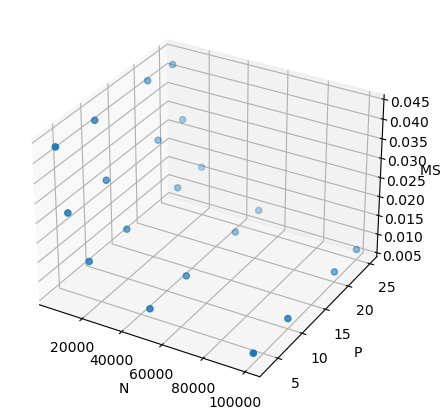

In [4]:
fig = plt.figure(figsize=(12, 4))  
ax = fig.add_subplot(projection='3d')
ax.scatter(s11mean.N, s11mean.P, s11mean.MSEA)
ax.set_xlabel('N')
ax.set_ylabel('P')
ax.set_zlabel('MSE ')
#ax.set_title('Simulation 1: 2 variables in mean - 0 variables in variance')

Text(0.5, 0, 'MSE ')

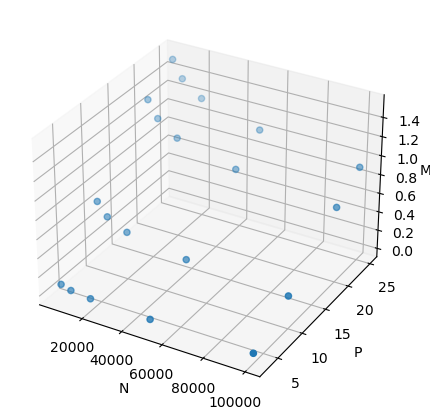

In [5]:
fig = plt.figure(figsize=(6, 4))  
ax = fig.add_subplot(projection='3d')
ax.scatter(s12mean.N, s12mean.P, s12mean.MSEA)
ax.set_xlabel('N')
ax.set_ylabel('P')
ax.set_zlabel('MSE ')
#ax.set_title('Simulation 1: 2 variables in mean - 0 variables in variance')

Text(0.5, 0, 'MSEV')

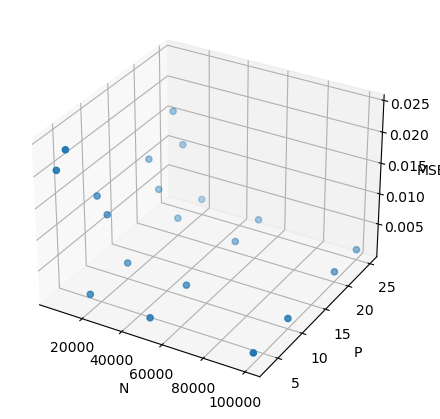

In [6]:
fig = plt.figure(figsize=(6, 4))  
ax = fig.add_subplot(projection='3d')
ax.scatter(s11mean.N, s11mean.P, s11mean.MSEV)
ax.set_xlabel('N')
ax.set_ylabel('P')
ax.set_zlabel('MSEV')
#ax.set_title('Simulation 1: 2 variables in mean - 0 variables in variance')

Text(0.5, 0, 'MSEV')

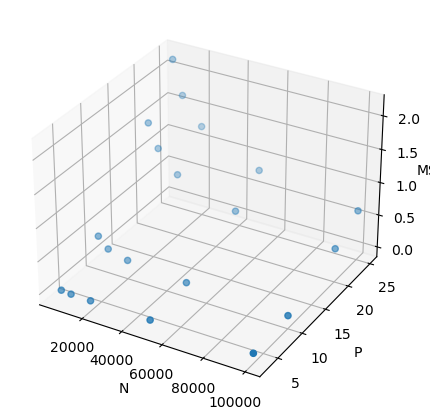

In [7]:
fig = plt.figure(figsize=(6, 4))  
ax = fig.add_subplot(projection='3d')
ax.scatter(s12mean.N, s12mean.P, s12mean.MSEV)
ax.set_xlabel('N')
ax.set_ylabel('P')
ax.set_zlabel('MSEV')
#ax.set_title('Simulation 1: 2 variables in mean - 0 variables in variance')

In [8]:
s21 = pd.read_csv('data/sim2.csv')
s22 = pd.read_csv('data/sim2_no.csv')
s21mean = s21.groupby(['N', 'P'])[['MSEA', 'MSEV']].mean().reset_index()
s22mean = s22.groupby(['N', 'P'])[['MSEA', 'MSEV']].mean().reset_index()
s21mean

,N,P,MSEA,MSEV
0,5000,3,0.0063,0.8026
1,5000,10,0.0069,0.6997
2,5000,20,0.0061,0.9310
3,5000,25,0.0053,1.1172
4,10000,3,0.0031,0.9373
5,10000,10,0.0025,0.6875
6,10000,20,0.0032,0.7145
7,10000,25,0.0035,0.8270
8,20000,3,0.0022,0.5057
9,20000,10,0.0025,0.5198


In [9]:
s22mean

,N,P,MSEA,MSEV
0,5000,3,0.0081,1.0415
1,5000,10,0.0063,1.4483
2,5000,20,0.0066,1.6663
3,5000,25,0.0054,1.7433
4,10000,3,0.0036,2.1614
5,10000,10,0.0037,1.3894
6,10000,20,0.0032,1.6022
7,10000,25,0.0033,1.7349
8,20000,3,0.0022,0.8711
9,20000,10,0.0023,1.2565


In [10]:
p3_1 = s21mean.loc[s11mean['P'] == 3, ['N', 'MSEA', 'MSEV']].reset_index(drop=True)
p10_1 = s21mean.loc[s11mean['P'] == 10, ['MSEA', 'MSEV']].reset_index(drop=True)
p20_1 = s21mean.loc[s11mean['P'] == 20, ['MSEA', 'MSEV']].reset_index(drop=True)
p25_1 = s21mean.loc[s11mean['P'] == 25, ['MSEA', 'MSEV']].reset_index(drop=True)

p3_2 = s22mean.loc[s11mean['P'] == 3, ['N', 'MSEA', 'MSEV']].reset_index(drop=True)
p10_2 = s22mean.loc[s11mean['P'] == 10, ['MSEA', 'MSEV']].reset_index(drop=True)
p20_2 = s22mean.loc[s11mean['P'] == 20, ['MSEA', 'MSEV']].reset_index(drop=True)
p25_2 = s22mean.loc[s11mean['P'] == 25, ['MSEA', 'MSEV']].reset_index(drop=True)

df1 = pd.concat([p3_1, p10_1, p20_1, p25_1], axis=1)
df1.index = pd.MultiIndex.from_tuples([
    ("FS", "1"), ("FS", "2"), ("FS", "3"), ("FS", "4"), ("FS", "5")
])

df2 = pd.concat([p3_2, p10_2, p20_2, p25_2], axis=1)
df2.index = pd.MultiIndex.from_tuples([
    ("NFS", "1"), ("NFS", "2"), ("NFS", "3"), ("NFS", "4"), ("FS", "5")
])

df = pd.concat([df1, df2], axis=0)
latex = df.style.format(precision=4).format_index(
    axis=1, formatter="${}$".format).hide(axis=0).to_latex(
        position='bt!',
        position_float="centering",
        hrules=False, 
        label="tab:med1", 
        column_format='c|c|cc|cc|cc|cc',
        caption="Performance evaluations in scenario 2 of the estimators $\overline{x}$ and $\hat{v}$ for the different K-NN graph settings described in the text with and without feature selection. We report the mean squared error averaging over 100 Monte Carlo simulations.",
)
print(latex)

\begin{table}[bt!]
\centering
\caption{Performance evaluations in scenario 2 of the estimators $\overline{x}$ and $\hat{v}$ for the different K-NN graph settings described in the text with and without feature selection. We report the mean squared error averaging over 100 Monte Carlo simulations.}
\label{tab:med1}
\begin{tabular}{c|c|cc|cc|cc|cc}
$N$ & $MSEA$ & $MSEV$ & $MSEA$ & $MSEV$ & $MSEA$ & $MSEV$ & $MSEA$ & $MSEV$ \\
5000 & 0.0063 & 0.8026 & 0.0069 & 0.6997 & 0.0061 & 0.9310 & 0.0053 & 1.1172 \\
10000 & 0.0031 & 0.9373 & 0.0025 & 0.6875 & 0.0032 & 0.7145 & 0.0035 & 0.8270 \\
20000 & 0.0022 & 0.5057 & 0.0025 & 0.5198 & 0.0023 & 0.5029 & 0.0019 & 0.5409 \\
50000 & 0.0091 & 0.0595 & 0.0049 & 0.0556 & 0.0032 & 0.0550 & 0.0082 & 0.0604 \\
100000 & 0.0072 & 0.0214 & 0.0064 & 0.0202 & 0.0038 & 0.0204 & 0.0043 & 0.0217 \\
5000 & 0.0081 & 1.0415 & 0.0063 & 1.4483 & 0.0066 & 1.6663 & 0.0054 & 1.7433 \\
10000 & 0.0036 & 2.1614 & 0.0037 & 1.3894 & 0.0032 & 1.6022 & 0.0033 & 1.7349 \\
20000 &

Text(0.5, 0, 'MSEA')

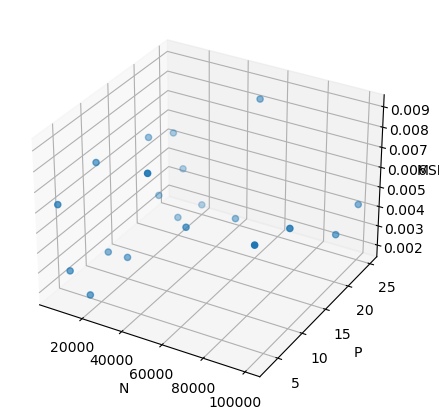

In [11]:
fig = plt.figure(figsize=(6, 4))  
ax = fig.add_subplot(projection='3d')
ax.scatter(s21mean.N, s21mean.P, s21mean.MSEA)
ax.set_xlabel('N')
ax.set_ylabel('P')
ax.set_zlabel('MSEA')
#ax.set_title('Simulation 2: 0 variables in mean - 1 variable in variance')

Text(0.5, 0, 'MSEA')

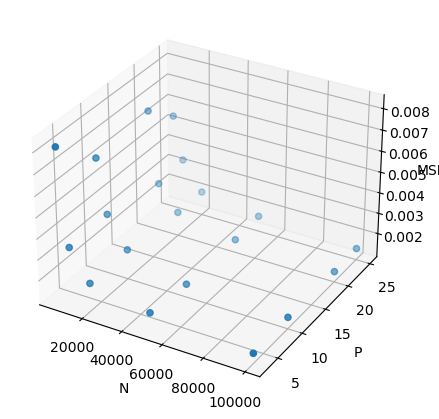

In [12]:
fig = plt.figure(figsize=(6, 4))  
ax = fig.add_subplot(projection='3d')
ax.scatter(s22mean.N, s22mean.P, s22mean.MSEA)
ax.set_xlabel('N')
ax.set_ylabel('P')
ax.set_zlabel('MSEA')
#ax.set_title('Simulation 2: 0 variables in mean - 1 variable in variance')

Text(0.5, 0, 'MSEV')

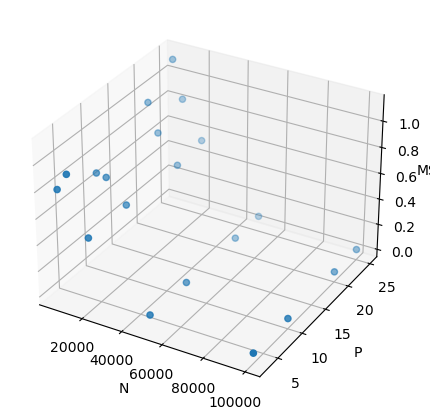

In [13]:
fig = plt.figure(figsize=(6, 4))  
ax = fig.add_subplot(projection='3d')
ax.scatter(s21mean.N, s21mean.P, s21mean.MSEV)
ax.set_xlabel('N')
ax.set_ylabel('P')
ax.set_zlabel('MSEV')
#ax.set_title('Simulation 2: 0 variables in mean - 1 variable in variance')

Text(0.5, 0, 'MSEV')

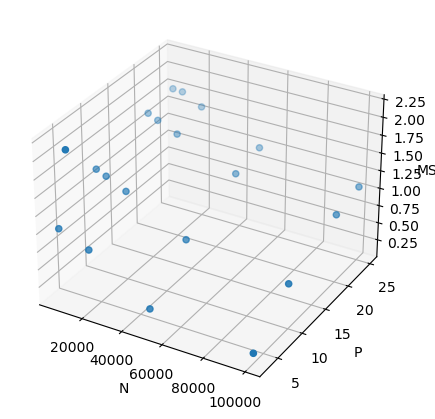

In [14]:
fig = plt.figure(figsize=(6, 4))  
ax = fig.add_subplot(projection='3d')
ax.scatter(s22mean.N, s22mean.P, s22mean.MSEV)
ax.set_xlabel('N')
ax.set_ylabel('P')
ax.set_zlabel('MSEV')
#ax.set_title('Simulation 2: 0 variables in mean - 1 variable in variance')

In [15]:
s31 = pd.read_csv('data/sim3.csv')
s32 = pd.read_csv('data/sim3_no.csv')
s31mean = s31.groupby(['N', 'P'])[['MSEA', 'MSEV']].mean().reset_index()
s32mean = s32.groupby(['N', 'P'])[['MSEA', 'MSEV']].mean().reset_index()
s31mean


,N,P,MSEA,MSEV
0,5000,3,0.0782,0.5546
1,5000,10,0.0770,0.7934
2,5000,20,0.0741,0.9381
3,5000,25,0.0743,0.8808
4,10000,3,0.0473,0.6874
5,10000,10,0.0482,0.6662
6,10000,20,0.0448,0.4978
7,10000,25,0.0476,0.7247
8,20000,3,0.0313,0.4962
9,20000,10,0.0316,0.4151


In [16]:
s32mean

,N,P,MSEA,MSEV
0,5000,3,0.1437,1.0584
1,5000,10,0.7315,1.9104
2,5000,20,1.3806,3.3652
3,5000,25,1.6027,4.0641
4,10000,3,0.0932,2.2468
5,10000,10,0.5888,1.6454
6,10000,20,1.1959,3.0601
7,10000,25,1.4157,3.3767
8,20000,3,0.0643,0.8605
9,20000,10,0.4889,1.4443


In [17]:
p3_1 = s31mean.loc[s11mean['P'] == 3, ['N', 'MSEA', 'MSEV']].reset_index(drop=True)
p10_1 = s31mean.loc[s11mean['P'] == 10, ['MSEA', 'MSEV']].reset_index(drop=True)
p20_1 = s31mean.loc[s11mean['P'] == 20, ['MSEA', 'MSEV']].reset_index(drop=True)
p25_1 = s31mean.loc[s11mean['P'] == 25, ['MSEA', 'MSEV']].reset_index(drop=True)

p3_2 = s32mean.loc[s11mean['P'] == 3, ['N', 'MSEA', 'MSEV']].reset_index(drop=True)
p10_2 = s32mean.loc[s11mean['P'] == 10, ['MSEA', 'MSEV']].reset_index(drop=True)
p20_2 = s32mean.loc[s11mean['P'] == 20, ['MSEA', 'MSEV']].reset_index(drop=True)
p25_2 = s32mean.loc[s11mean['P'] == 25, ['MSEA', 'MSEV']].reset_index(drop=True)

df1 = pd.concat([p3_1, p10_1, p20_1, p25_1], axis=1)
df1.index = pd.MultiIndex.from_tuples([
    ("FS", "1"), ("FS", "2"), ("FS", "3"), ("FS", "4"), ("FS", "5")
])

df2 = pd.concat([p3_2, p10_2, p20_2, p25_2], axis=1)
df2.index = pd.MultiIndex.from_tuples([
    ("NFS", "1"), ("NFS", "2"), ("NFS", "3"), ("NFS", "4"), ("FS", "5")
])

df = pd.concat([df1, df2], axis=0)
latex = df.style.format(precision=4).format_index(
    axis=1, formatter="${}$".format).hide(axis=0).to_latex(
        position='bt!',
        position_float="centering",
        hrules=False, 
        label="tab:med1", 
        column_format='c|c|cc|cc|cc|cc',
        caption="Performance evaluations in scenario 1 of the estimators $\overline{x}$ and $\hat{v}$ for the different K-NN graph settings described in the text with and without feature selection. We report the mean squared error averaging over 100 Monte Carlo simulations.",
)
print(latex)

\begin{table}[bt!]
\centering
\caption{Performance evaluations in scenario 1 of the estimators $\overline{x}$ and $\hat{v}$ for the different K-NN graph settings described in the text with and without feature selection. We report the mean squared error averaging over 100 Monte Carlo simulations.}
\label{tab:med1}
\begin{tabular}{c|c|cc|cc|cc|cc}
$N$ & $MSEA$ & $MSEV$ & $MSEA$ & $MSEV$ & $MSEA$ & $MSEV$ & $MSEA$ & $MSEV$ \\
5000 & 0.0782 & 0.5546 & 0.0770 & 0.7934 & 0.0741 & 0.9381 & 0.0743 & 0.8808 \\
10000 & 0.0473 & 0.6874 & 0.0482 & 0.6662 & 0.0448 & 0.4978 & 0.0476 & 0.7247 \\
20000 & 0.0313 & 0.4962 & 0.0316 & 0.4151 & 0.0312 & 0.5146 & 0.0310 & 0.5302 \\
50000 & 0.0179 & 0.0583 & 0.0184 & 0.0526 & 0.0167 & 0.0653 & 0.0171 & 0.0519 \\
100000 & 0.0109 & 0.0191 & 0.0114 & 0.0193 & 0.0110 & 0.0180 & 0.0113 & 0.0211 \\
5000 & 0.1437 & 1.0584 & 0.7315 & 1.9104 & 1.3806 & 3.3652 & 1.6027 & 4.0641 \\
10000 & 0.0932 & 2.2468 & 0.5888 & 1.6454 & 1.1959 & 3.0601 & 1.4157 & 3.3767 \\
20000 &

Text(0.5, 0, 'MSEA')

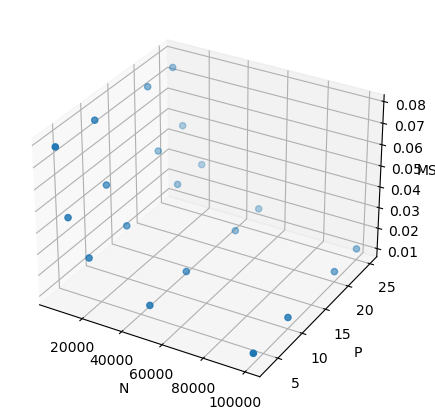

In [18]:
fig = plt.figure(figsize=(6, 4))  
ax = fig.add_subplot(projection='3d')
ax.scatter(s31mean.N, s31mean.P, s31mean.MSEA)
ax.set_xlabel('N')
ax.set_ylabel('P')
ax.set_zlabel('MSEA')
#ax.set_title('Simulation 3: 2 variables in mean - 1 variable in variance')

Text(0.5, 0, 'MSEA')

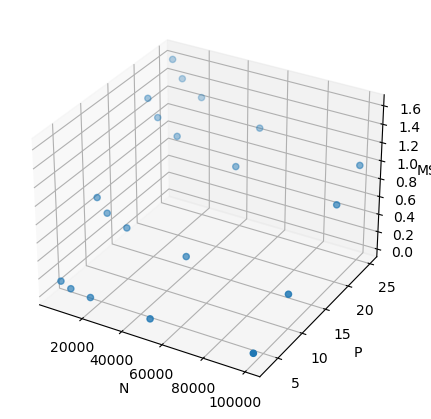

In [19]:
fig = plt.figure(figsize=(6, 4))  
ax = fig.add_subplot(projection='3d')
ax.scatter(s32mean.N, s32mean.P, s32mean.MSEA)
ax.set_xlabel('N')
ax.set_ylabel('P')
ax.set_zlabel('MSEA')
#ax.set_title('Simulation 3: 2 variables in mean - 1 variable in variance')

Text(0.5, 0, 'MSEV')

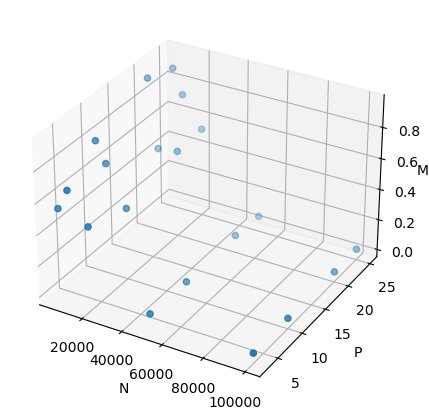

In [20]:
fig = plt.figure(figsize=(6, 4))  
ax = fig.add_subplot(projection='3d')
ax.scatter(s31mean.N, s31mean.P, s31mean.MSEV)
ax.set_xlabel('N')
ax.set_ylabel('P')
ax.set_zlabel('MSEV')
#ax.set_title('Simulation 3: 2 variables in mean - 1 variable in variance')

Text(0.5, 0, 'MSEV')

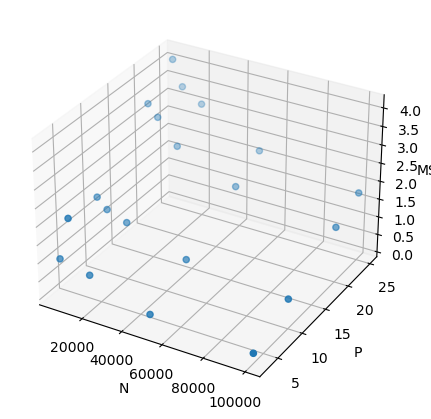

In [21]:
fig = plt.figure(figsize=(6, 4))  
ax = fig.add_subplot(projection='3d')
ax.scatter(s32mean.N, s32mean.P, s32mean.MSEV)
ax.set_xlabel('N')
ax.set_ylabel('P')
ax.set_zlabel('MSEV')
#ax.set_title('Simulation 3: 2 variables in mean - 1 variable in variance')